# [Lab 1](https://colab.research.google.com/github/deeplife4eu/Lecture-materials/blob/main/Week_01/Deep4Life_Lab_1_Introduction_to_pytorch_noSolution.ipynb#scrollTo=tX_iAGqv1yd2): introduction to PyTorch

If the library is not available, install it running <code>pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126</code> through the terminal. Make sure that it is not the cpu version: if you run <code>torch.__version__</code> and it shows something along the lines of 2.x.x+cpu, it is the wrong one.

I had some problems: in synthesis, the GPU was found when running the commands on terminal (<code>python -c "import torch; print(torch.__version__); print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"</code>), but not on Visual Studio Code, where I am running the commands.

I checked the directory of Python with <code>where.exe python</code>. Then added that interpreter on Visual Studio Code with Ctrl + Shift + P, typing Python: Select Interpreter and pasting the path.

In [1]:
import torch
print(f'pytorch version: {torch.__version__}')
num_gpu = torch.cuda.device_count()
print(f'{num_gpu} GPU available')

pytorch version: 2.14.1+cu126
1 GPU available


## Linear regression

Now that we have a GPU available, we are going to try out neural networks starting from a simple task: a linear regression.

As training set, we will generate a dataset from a linear function: the objective is, for our model, to estimate this function starting from the observed points.

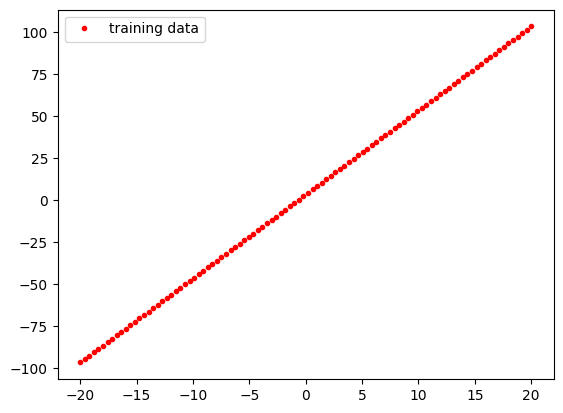

In [2]:
import matplotlib.pyplot as plt
import numpy as np

Xs = np.linspace(-20,20,100) # we start with a hundered X values between -20 and 20

Ys=Xs*5+3.5 # as our Xs are a numpy array, we can perform simple arithmetic on each element of Xs

#Now, we can plot the data we generated

plt.plot(Xs,Ys,"r.",label="training data")
plt.legend()

Now we will set up a very simple neural network with 1 input layer, 1 output layer and 4 hidden layers. Remember that the library PyTorch uses numpy arrays, so we have to define the type of data that goes in them (<code>dtype</code>), and then we need to reshape them into "torch vectors". Other things we have to define, are:
- the Loss Function (in this case MSE, but for a Logistic Regression, for example, we would use Log-Loss);
- the optimizer (in this case SGD with a very small learning rate, but another popular choice is ADAm).

In [5]:
import torch.nn as nn

#we set the parameters of our simple network architecture
N_input=1
N_hidden=4
N_output=1

#create the model based on these parameters
model = nn.Sequential(
    nn.Linear(N_input, N_hidden),
    nn.Linear(N_hidden, N_output),
)

#convert our numpy arrays Xs and Ys into torch vectors we can use in training
inputs = torch.tensor(Xs.reshape((100,1)), dtype=torch.float32)
targets = torch.tensor(Ys.reshape((100,1)), dtype=torch.float32)

# We define the Loss function (Mean Square Error in this case, since this is a 
# linear regression task).
criterion =  torch.nn.MSELoss() 

# Construct the optimizer (Stochastic Gradient Descent in this case)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001) 
# lr is the learning rate


We also set up a training loop. Remember: the number of epochs is, in simple terms, how many times we want the model to cycle through the neurons layers to try and converge to a model with the smallest Loss function possible.

epoch:  0  loss:  4828.58984375
epoch:  100  loss:  2.053626298904419
epoch:  200  loss:  1.5812166929244995
epoch:  300  loss:  1.211993932723999
epoch:  400  loss:  0.9250337481498718
epoch:  500  loss:  0.7032108902931213
epoch:  600  loss:  0.5326249599456787
epoch:  700  loss:  0.40207213163375854
epoch:  800  loss:  0.30259594321250916
epoch:  900  loss:  0.22711211442947388
epoch:  1000  loss:  0.1700417399406433
epoch:  1100  loss:  0.12703929841518402
epoch:  1200  loss:  0.09472808986902237
epoch:  1300  loss:  0.07051832973957062
epoch:  1400  loss:  0.05241577327251434
epoch:  1500  loss:  0.03891151025891304
epoch:  1600  loss:  0.02885298803448677
epoch:  1700  loss:  0.02137398160994053
epoch:  1800  loss:  0.01581978052854538
epoch:  1900  loss:  0.01170052494853735
epoch:  2000  loss:  0.008648622781038284
epoch:  2100  loss:  0.006389087066054344
epoch:  2200  loss:  0.004717537667602301
epoch:  2300  loss:  0.003482039086520672
epoch:  2400  loss:  0.0025689657777547

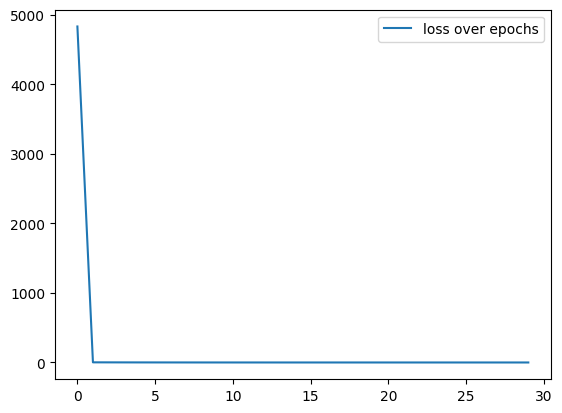

In [6]:
N_epochs=3000
loss_vals=[]
# Gradient Descent
for epoch in range(N_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(inputs)

    # Compute and print loss
    loss = criterion(y_pred, targets)
    # Every 100 epochs, print the loss value, just to keep track
    if epoch % 100 == 0: 
        print('epoch: ', epoch, ' loss: ', loss.item())
        loss_vals.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()

    # perform a backward pass (backpropagation)
    loss.backward()

    # Update the parameters
    optimizer.step()

plt.plot(loss_vals,label="loss over epochs")
plt.legend()

If we do just a tiny little zoom we can get some information on how the model learns: the first steps are important to drastically reduce the Loss error, but the last ones slowly bring the Loss function close to 0. In the tutorial, the zoom was originally (-.5,15), but I changed it to (-.5,2) to better visualize the loss values of my neural network. The fact that I can reach way smaller values of loss than the tutorial is a good sign that my neural network is learning well. 

(-0.1, 2.0)

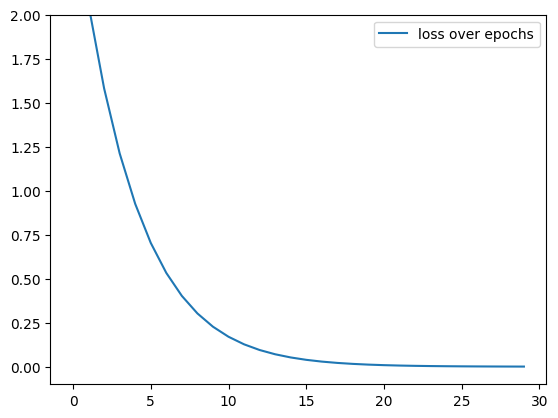

In [9]:
plt.plot(loss_vals,label="loss over epochs")
plt.legend()
plt.ylim(-.1,2) 

Now that we have a model that is ready, we can see how it behaves on test data. We will generate some more few points and see how the model will act.

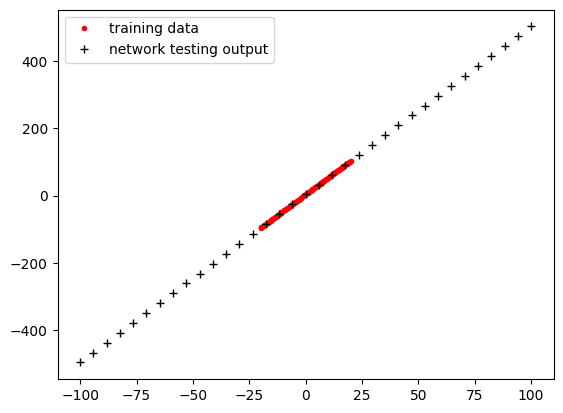

In [10]:
test_Xs= np.linspace(-100,100,35)
test_Ys=test_Xs*5+3.5

with torch.no_grad(): # turning off the autograd of PyTorch
    test_data = torch.tensor(test_Xs.reshape((35,1)), dtype=torch.float32)
    test_output = model(test_data)

#plot the results
plt.plot(Xs,Ys,"r.",label="training data")
plt.plot(test_Xs,test_output,"k+",label="network testing output")
plt.legend()